In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [6]:
df = pd.read_csv("Salary_Data.csv")
df.head()


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [7]:
x = df['YearsExperience'].values
y = df['Salary'].values


In [8]:
print(df.shape)

(30, 2)


In [9]:
df.head() #Top 4 rows

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [10]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [11]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


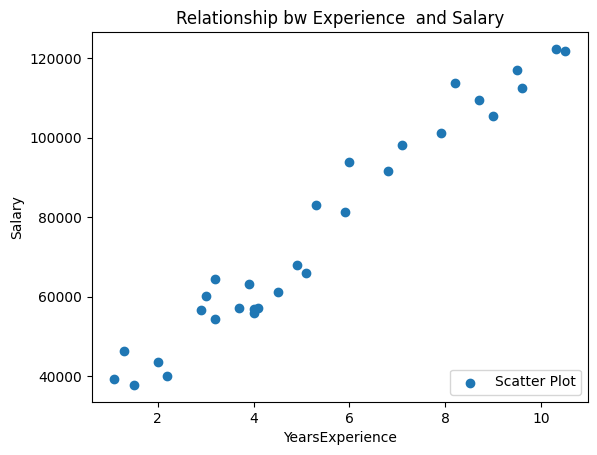

In [12]:
#Visual EDA
plt.scatter(x,y, label='Scatter Plot')
plt.title("Relationship bw Experience  and Salary")
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.legend(loc=4)
plt.show()

In [13]:
print(x.shape)
print(y.shape)
#Dimensions of x and y

(30,)
(30,)


In [14]:
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)
#Reshaping x and y
print(x.shape)
print(y.shape) #New dimensions

(30, 1)
(30, 1)


In [16]:
#Split x and y into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [17]:
#Fit the linear model
from sklearn.linear_model import LinearRegression
lm = LinearRegression() #Instantiate the linear regression object

lm.fit(x_train, y_train) #Train the model using training datasets

y_pred = lm.predict(x_test) #Make predictions using testing set


In [18]:
a = lm.coef_
b = lm.intercept_
print("Estimated model slope: ",a)
print("Estimated model intercept: ",b)
#

Estimated model slope:  [[9423.81532303]]
Estimated model intercept:  [25321.58301178]


In [19]:
#Calculate RMSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE value: {:.4f}".format(rmse))

RMSE value: 7059.0436


In [20]:
#Calculate R2 score
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 score value: {:.4f}".format(r2))

R2 score value: 0.9024


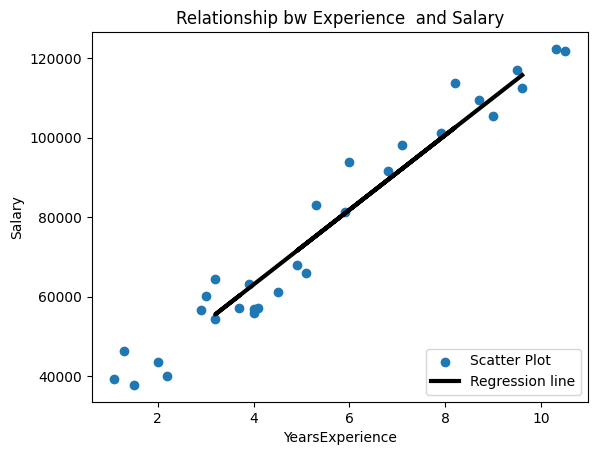

In [21]:
#Visual EDA
plt.scatter(x,y, label='Scatter Plot')
plt.plot(x_test, y_pred, color='black', linewidth=3, label = 'Regression line')
plt.title("Relationship bw Experience  and Salary")
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.legend(loc=4)
plt.show()

In [22]:
print("Training set score: {:.4f}".format(lm.score(x_train, y_train)))
print("Test set score: {:.4f}".format(lm.score(x_test, y_test)))

Training set score: 0.9645
Test set score: 0.9024
